In [1]:
import numpy as np
import scanpy as sc
from scipy.spatial import distance
from sklearn.metrics import pairwise_distances
from pathlib import Path

from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot
)

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
section_ids_list = [['151675', '151675']]

for section_ids in section_ids_list:
    dataset = section_ids[0] + '_' + section_ids[1]

    sliceA = _load_data.load_DLPFC(section_id=section_ids[0])
    sliceB = _load_data.load_DLPFC(section_id=section_ids[1])

random_state = 23
np.random.seed(random_state)


/Users/salovjade/Library/CloudStorage/Dropbox/raftup_repo/src/raftup/_load_data.py:12: FutureWarning: Use `squidpy.read.visium` instead.
  ad = sc.read_visium(path=os.path.join(root_dir, section_id), count_file=section_id+'_filtered_feature_bc_matrix.h5')
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/salovjade/Library/CloudStorage/Dropbox/raftup_repo/src/raftup/_load_data.py:12: FutureWarning: Use `squidpy.read.visium` instead.
  ad = sc.read_visium(path=os.path.join(root_dir, section_id), count_file=section_id+'_filtered_feature_bc_matrix.h5')
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


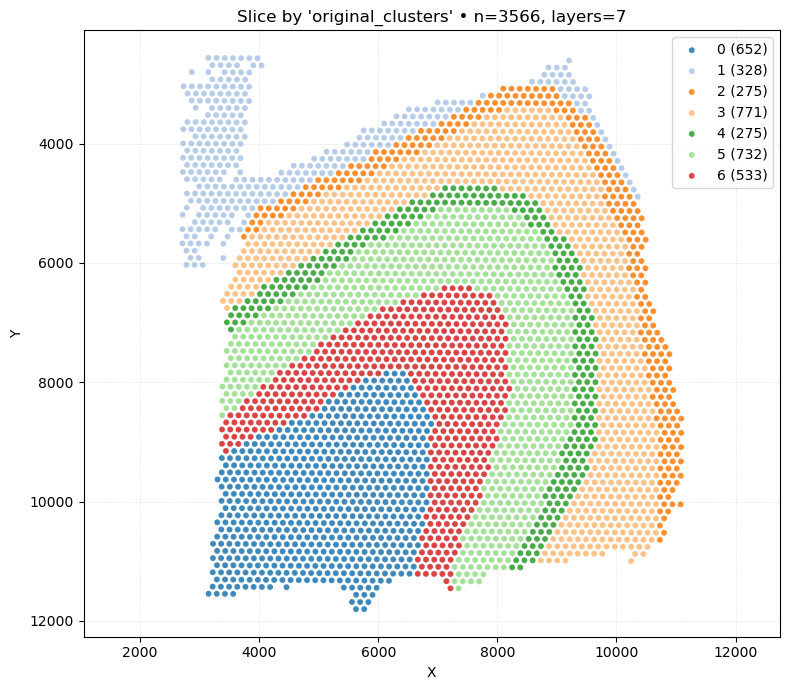

{'0': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 '1': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
 '2': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 '3': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
 '4': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 '5': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
 '6': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)}

In [3]:
#_downsample.visualize_downsampled_points(sliceA, sliceA)

_plot.plot_slice_by_layer(sliceA, equal_aspect=True)

Sub-slice contains 135 points


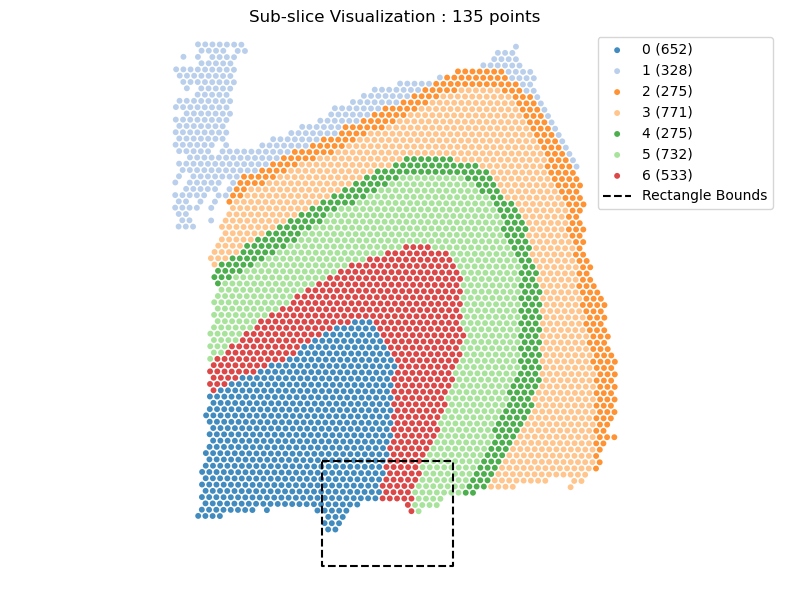

✅ Sub-slice saved to ./data/simple_overlapping_subsliceA.h5ad


{'0': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 '1': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
 '2': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 '3': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
 '4': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 '5': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
 '6': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)}

In [4]:
# rect_bounds: tuple (xmin, xmax, ymin, ymax)

_downsample.visualize_subslice(sliceA, rect_bounds=(5500, 8000, 10500, 12500), max_points=200, save_path="./data/simple_overlapping_subsliceA.h5ad")

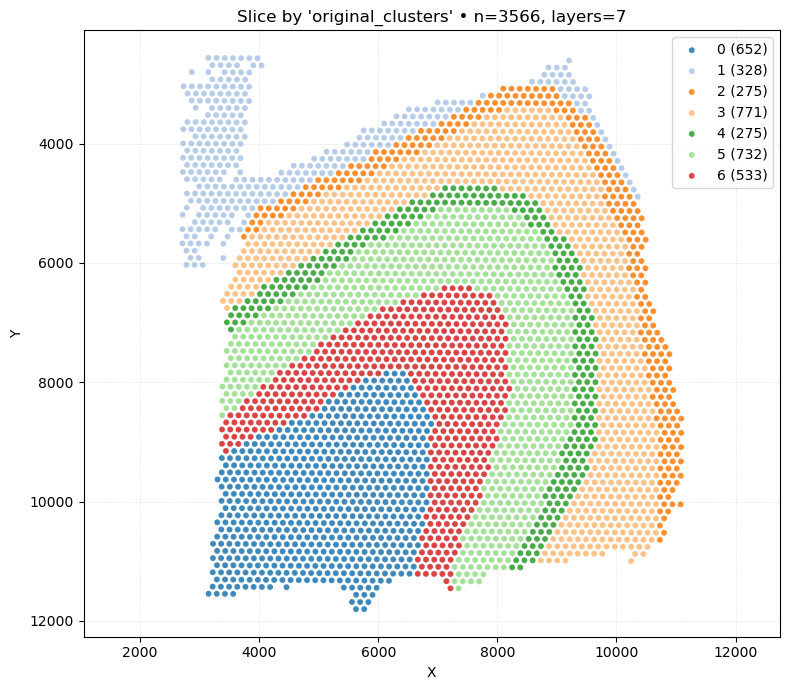

{'0': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 '1': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
 '2': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 '3': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
 '4': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 '5': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
 '6': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)}

In [5]:
_plot.plot_slice_by_layer(sliceB, equal_aspect=True)

Sub-slice contains 112 points


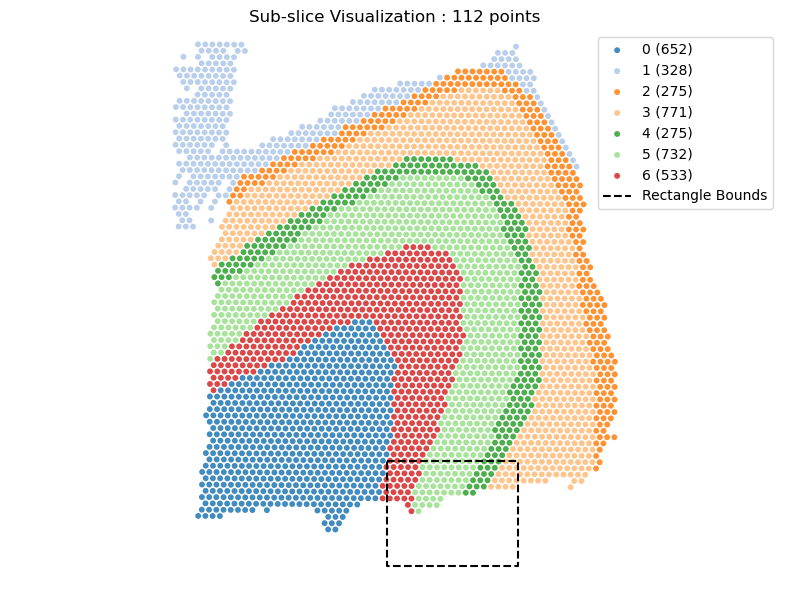

✅ Sub-slice saved to ./data/simple_overlapping_subsliceB.h5ad


{'0': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 '1': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
 '2': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 '3': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0),
 '4': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0),
 '5': (0.596078431372549, 0.8745098039215686, 0.5411764705882353, 1.0),
 '6': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)}

In [6]:
_downsample.visualize_subslice(sliceB, rect_bounds=(6750, 9250, 10500, 12500), max_points=200, save_path="./data/simple_overlapping_subsliceB.h5ad")

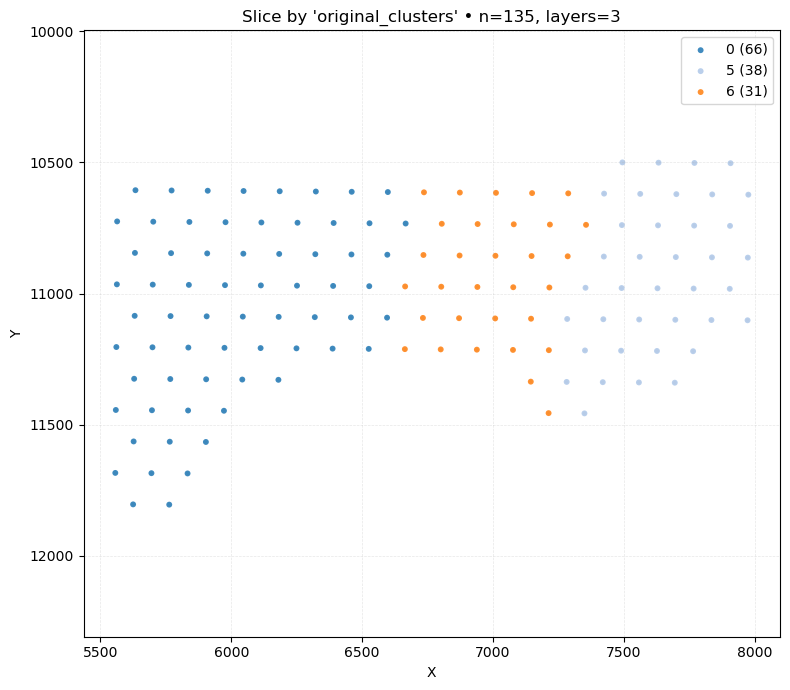

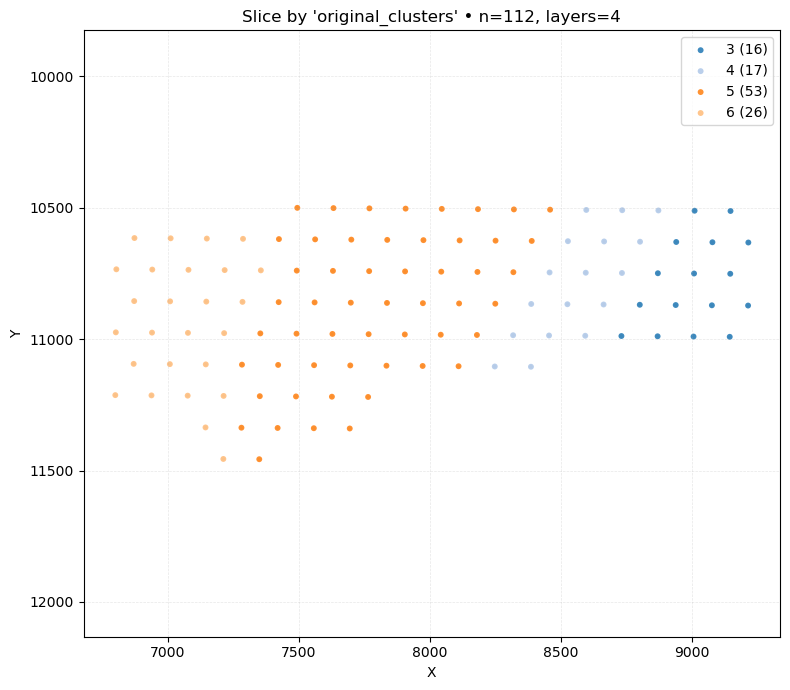

{'3': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 '4': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274, 1.0),
 '5': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0),
 '6': (1.0, 0.7333333333333333, 0.47058823529411764, 1.0)}

In [7]:


# Load the AnnData object from .h5ad file
sliceA_sub = sc.read_h5ad("./data/simple_overlapping_subsliceA.h5ad")
sliceB_sub = sc.read_h5ad("./data/simple_overlapping_subsliceB.h5ad")

_plot.plot_slice_by_layer(sliceA_sub, equal_aspect=True)
_plot.plot_slice_by_layer(sliceB_sub, equal_aspect=True)

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


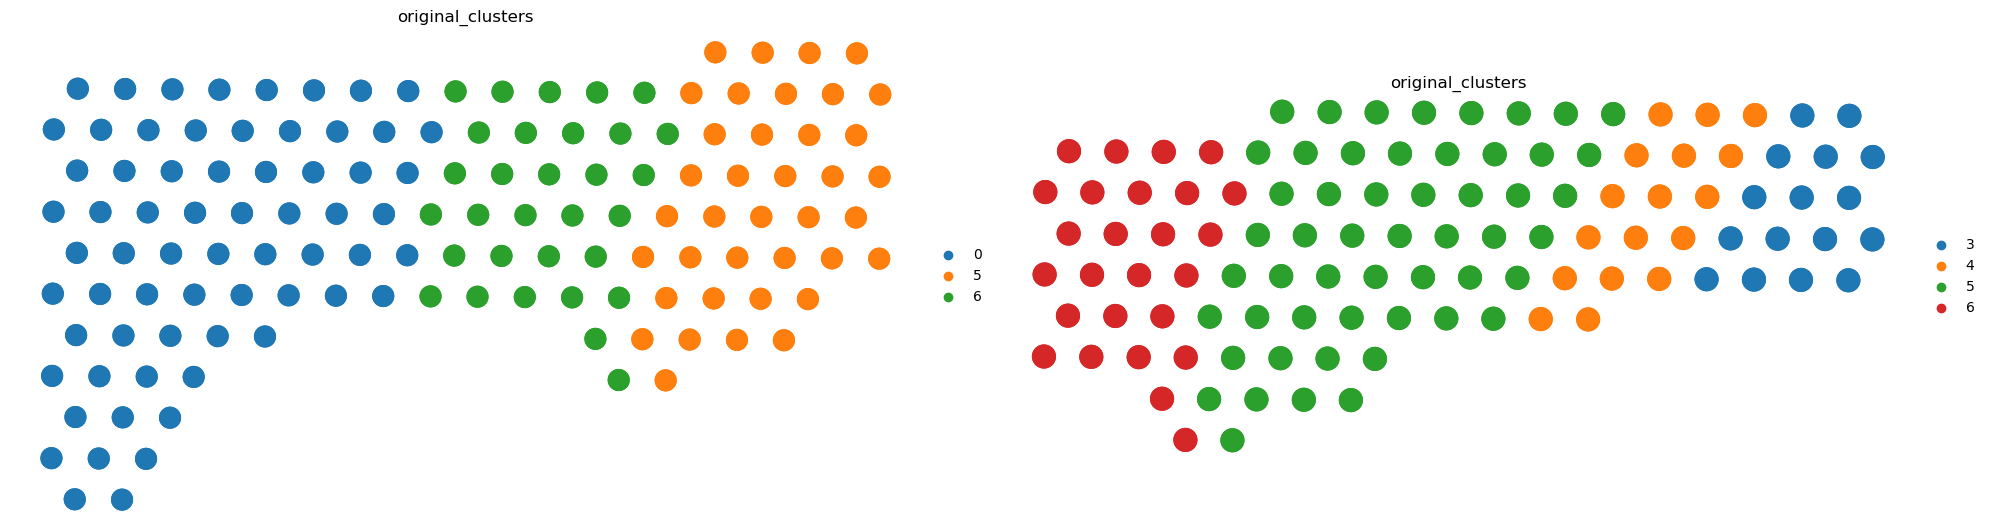

In [8]:
import matplotlib.pyplot as plt
import squidpy as sq

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sq.pl.spatial_scatter(
    sliceA_sub,
    frameon=False,
    shape=None,
    color='original_clusters',
    figsize=(10, 6),
    ax=axes[0]
)

sq.pl.spatial_scatter(
    sliceB_sub,
    frameon=False,
    shape=None,
    color='original_clusters',
    figsize=(10, 6),
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [9]:
indices_dsa = []
for point in sliceA_sub.obsm['spatial']:
    index = np.where((sliceA.obsm['spatial'] == point).all(axis=1))[0]
    if len(index) > 0: 
        indices_dsa.append(index[0])

In [10]:
indices_dsb = []
for point in sliceB_sub.obsm['spatial']:
    index = np.where((sliceB.obsm['spatial'] == point).all(axis=1))[0]
    if len(index) > 0: 
        indices_dsb.append(index[0])

In [11]:
common = sliceA_sub.var_names.intersection(sliceB_sub.var_names)
a1 = sliceA_sub[:, common].copy()
a2 = sliceB_sub[:, common].copy()

sc.pp.normalize_total(a1, target_sum=1e4); sc.pp.log1p(a1)
sc.pp.normalize_total(a2, target_sum=1e4); sc.pp.log1p(a2)


a = a1.concatenate(a2, batch_key="batch", batch_categories=["a1","a2"])

sc.pp.scale(a, max_value=10)      
sc.tl.pca(a, n_comps=50)


Z = a.obsm["X_pca"]
Z1 = Z[a.obs["batch"] == "a1"]
Z2 = Z[a.obs["batch"] == "a2"]

M_pca = pairwise_distances(Z1, Z2, metric="euclidean")
print(M_pca.shape)

np.save("./results/gene_cost_matrix/test_2_M_pca.npy", M_pca) 

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/merge.py:1015: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  concat_indices = concat_indices.str.cat(label_col.map(str), sep=index_unique)
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/merge.py:1015: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na

(135, 112)


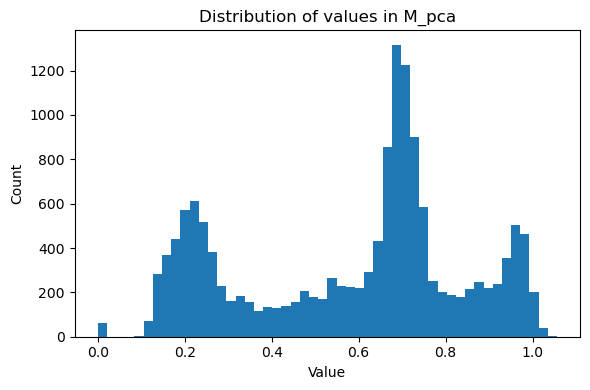

In [12]:
import numpy as np
import matplotlib.pyplot as plt

p99_pca = np.percentile(M_pca[M_pca > 0], 99)
M_norm_pca = M_pca / (p99_pca + 1e-12)


# M: (n1, n2) matrix
vals = M_norm_pca.flatten()

plt.figure(figsize=(6, 4))
plt.hist(vals, bins=50)  
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution of values in M_pca")
plt.tight_layout()
plt.show()

In [13]:

D_A_test = distance.cdist(sliceA_sub.obsm['spatial'], sliceA_sub.obsm['spatial'])
D_B_test = distance.cdist(sliceB_sub.obsm['spatial'], sliceB_sub.obsm['spatial'])

testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
print(np.min(testA), np.min(testB))

137.00364958642524 137.00364958642524


In [14]:
import numpy as np
from pathlib import Path
from tqdm import tqdm

from raftup import _metrics_two_gpr
from raftup import _fsgw_utils as _fsgw


# ======================
# Paths (DO NOT depend on cwd)
# ======================

from pathlib import Path

SAVE_DIR = "./results/align_data"

# ======================
# Parameters
# ======================
cutoff_GW_list = [50]
cutoff_CC_list = [0.1]


# ======================
# Main loop
# ======================
for cutoff_GW in cutoff_GW_list:
    for cutoff_CC in cutoff_CC_list:

        print(f"\nRunning ds with GW cutoff = {cutoff_GW}, CC cutoff = {cutoff_CC}")

        P = _fsgw_utils.fsgw_mvc_exp(
            D_A_test,
            D_B_test,
            M_norm_pca,
            gw_cutoff=cutoff_GW,
            w_cutoff=cutoff_CC
        )

        print("P.sum():", P.sum())

        test_label_full = np.concatenate(
            (
                np.array(sliceA_sub.obs["original_clusters"]),
                np.array(sliceB_sub.obs["original_clusters"]),
            ),
            axis=0,
        )

        XA_full = sliceA_sub.obsm["spatial"]
        XB_full = sliceB_sub.obsm["spatial"]

        full_window_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_full_skip_all_zero(
            P, test_label_full
        )

        full_window_GPR_150 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=150, P_cut=1e-20
        )
        full_window_GPR_300 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=300, P_cut=1e-20
        )
        full_window_GPR_450 = _metrics_two_gpr.GPR_original(
            P, XA_full, XB_full, dis_cut=450, P_cut=1e-20
        )

        print(f"full_raftup_LAA for {section_ids}:", full_window_LAA[0])
        print("full_window_GPR_150:", full_window_GPR_150)
        print("full_window_GPR_300:", full_window_GPR_300)
        print("full_window_GPR_450:", full_window_GPR_450)
        print("---------------------------------------------------------------")

        np.save(f"./results/align_data/alignment_overlapping_window_GW{cutoff_GW}_CC{cutoff_CC}", P)



Running ds with GW cutoff = 50, CC cutoff = 0.1


sOT Iterations: 100%|██████████| 10000/10000 [00:01<00:00, 9139.36it/s]


P.sum(): 0.47407407407405333
1.0 0.0 0.0 0.0 0.0 0.0 0.0
full_raftup_LAA for ['151675', '151675']: 1.0
full_window_GPR_150: 1.0
full_window_GPR_300: 1.0
full_window_GPR_450: 1.0
---------------------------------------------------------------


In [15]:
adata_1 = sc.read_h5ad("./data/simple_overlapping_subsliceA.h5ad")
adata_2 = sc.read_h5ad("./data/simple_overlapping_subsliceB.h5ad")

X1 = adata_1.obsm["spatial"]
X2 = adata_2.obsm["spatial"]

P_raftup_window = np.load("./results/align_data/alignment_overlapping_window_GW50_CC0.1.npy")



In [16]:
test_label_full = np.concatenate((np.array(adata_1.obs['original_clusters']),np.array(adata_2.obs['original_clusters'])),axis=0)
XA_full = adata_1.obsm['spatial']
XB_full = adata_2.obsm['spatial']


full_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_full_skip_all_zero(P_raftup_window, test_label_full)
full_GPR_150= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=150, P_cut=1e-20)
full_GPR_300= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=300, P_cut=1e-20)
full_GPR_450= _metrics_two_gpr.GPR_original(P_raftup_window, XA_full, XB_full, dis_cut=450, P_cut=1e-20)

print(f"full_raftup_LAA for small window:", full_LAA [0])

print("full_raftup_GPR_150):", full_GPR_150)
print("full_raftup_GPR_300):", full_GPR_300)
print("full_raftup_GPR_450):", full_GPR_450)
print("---------------------------------------------------------------")

1.0 0.0 0.0 0.0 0.0 0.0 0.0
full_raftup_LAA for small window: 1.0
full_raftup_GPR_150): 1.0
full_raftup_GPR_300): 1.0
full_raftup_GPR_450): 1.0
---------------------------------------------------------------


In [17]:
P_raftup_window.sum()

0.47407407407405333

In [18]:

XA = np.asarray(adata_1.obsm["spatial"])
XB = np.asarray(adata_2.obsm["spatial"])

A_set = set(map(tuple, XA))
B_set = set(map(tuple, XB))

n_overlap = len(A_set & B_set)
print("Ground truth overlap count:", n_overlap)

n_nonzero_rows = np.count_nonzero(np.any(P_raftup_window != 0, axis=1))
print('Aligned pairs by P_raftup_window', n_nonzero_rows)

Ground truth overlap count: 64
Aligned pairs by P_raftup_window 64
